In [3]:
# 1. Import the tools we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
# 2. Get the data
# This is a list of thousands of messages labeled as 'spam' or 'ham' (normal)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_table(url, header=None, names=['label', 'message'])

In [5]:
# 3. Look at the data
print("Checking the first few rows:")
print(df.head())
print("\nCounting how many spam and ham messages we have:")
print(df['label'].value_counts())



Checking the first few rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Counting how many spam and ham messages we have:
label
ham     4825
spam     747
Name: count, dtype: int64


In [16]:
# --- STEP 4: Convert 'Ham' and 'Spam' into 0 and 1 (The Answers) ---
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# We transform only the 'label' column.
# Now the computer knows 0 = ham and 1 = spam.
df['label'] = le.fit_transform(df['label'])

print("--- Step 4 Result: The Label Column ---")
print(df[['label', 'message']].head()) # Messages are still text, labels are numbers




--- Step 4 Result: The Label Column ---
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [7]:
# 5. Pick our Input (X) and Output (y)
X = df['message']
y = df['label']

In [8]:
# 6. Split the data into two parts
# 80% to teach the model and 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# --- STEP 7: Convert Messages into Word Counts (The Clues) ---
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize the vectorizer
vectorizer = CountVectorizer()

# 2. Transform the text messages into a grid of numbers (Vectorization)
# We use NEW variable names (X_train_vec and X_test_vec) to keep the data safe
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("\n--- Step 7 Result: How the AI sees a message ---")
# Let's peek at the first 5 rows of the numerical grid
vectorized_sample = pd.DataFrame(X_train_vec.toarray()[:5], columns=vectorizer.get_feature_names_out())
print(vectorized_sample.head())




--- Step 7 Result: How the AI sees a message ---
   00  000  000pes  008704050406  0089  0121  01223585236  01223585334  02  \
0   0    0       0             0     0     0            0            0   0   
1   0    0       0             0     0     0            0            0   0   
2   0    0       0             0     0     0            0            0   0   
3   0    0       0             0     0     0            0            0   0   
4   0    0       0             0     0     0            0            0   0   

   0207  ...  zeros  zhong  zindgi  zoe  zogtorius  zoom  zouk  zyada  èn  ú1  
0     0  ...      0      0       0    0          0     0     0      0   0   0  
1     0  ...      0      0       0    0          0     0     0      0   0   0  
2     0  ...      0      0       0    0          0     0     0      0   0   0  
3     0  ...      0      0       0    0          0     0     0      0   0   0  
4     0  ...      0      0       0    0          0     0     0      0   0   0  



In [18]:
# 8. Train the AI model
model = MultinomialNB()

# Use 'X_train_vec' instead of 'X_train'
model.fit(X_train_vec, y_train)

MultinomialNB()

In [21]:
# --- Step 9: See how well it did ---

# 1. The model makes guesses (predictions) on the test data
y_pred = model.predict(X_test_vec)

# 2. This line compares the guesses (y_pred) to the real answers (y_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

# 3. This line prints the result you see on your screen
print("Accuracy:", accuracy)

Accuracy: 0.9919282511210762



Full Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



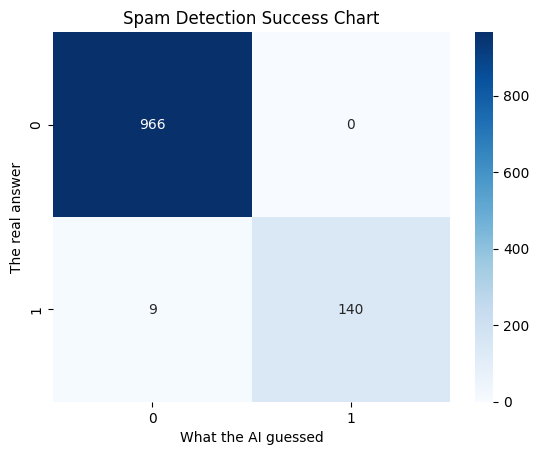

In [20]:
# 10. Show a report and a chart
print("\nFull Report:")
print(classification_report(y_test, y_pred))

# This creates the success chart (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("What the AI guessed")
plt.ylabel("The real answer")
plt.title("Spam Detection Success Chart")
plt.show()